In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/clinical_summaries.csv")
df.head(20)

,summary_id,patient_id,patient_age,patient_gender,diagnosis,body_temp_c,blood_pressure_systolic,heart_rate,summary_text,date_recorded
0,CS000001,P002538,61.0,M,COVID-19,34.416801,126.632921,92.000000,COVID-19 PCR positive.,2024-08-14
1,CS000002,P002869,NaN,F,Typhoid,34.899780,102.679066,88.000000,"Abdominal pain, nausea.",2024-11-11
2,CS000003,NaN,20.0,F,Typhoid,32.243013,124.862591,94.000000,"Abdominal pain, nausea.",2024-12-07
3,CS000004,P004611,25.0,M,Anemia,39.070247,123.192566,71.000000,Positive malaria test.,2025-06-11
4,CS000005,P006581,NaN,M,Anemia,34.377840,NaN,79.000000,Elevated enzymes.,2025-04-14
5,CS000006,P006534,48.0,F,Typhoid,37.934823,106.621866,97.000000,"Chronic fatigue, joint pain.",NaN
6,CS000007,NaN,36.0,M,Anemia,40.533221,130.280714,60.000000,"Fever, chills, headache.",2024-12-21
7,CS000008,P007031,84.0,F,Typhoid,34.224721,137.979799,78.000000,Positive malaria test.,2024-08-25
8,NaN,P000297,62.0,F,Dengue,37.198795,101.077457,87.000000,"Abdominal pain, nausea.",2024-08-12
9,CS000010,P005627,79.0,F,Hepatitis,37.640062,116.091576,66.000000,"Fever, chills, headache.",2025-05-15


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   summary_id               44939 non-null  object 
 1   patient_id               44996 non-null  object 
 2   patient_age              45031 non-null  float64
 3   patient_gender           44948 non-null  object 
 4   diagnosis                45037 non-null  object 
 5   body_temp_c              44936 non-null  float64
 6   blood_pressure_systolic  45037 non-null  float64
 7   heart_rate               44996 non-null  float64
 8   summary_text             44785 non-null  object 
 9   date_recorded            44934 non-null  object 
dtypes: float64(4), object(6)
memory usage: 3.8+ MB


- Changer le format de l'âge des patients en entiers

- Changer le format de date recorded en type date

- Mettre tout les diagnostics en miniscules

In [ ]:

#Changer le format de date recorded en type date
df['date_recorded'] = pd.to_datetime(df['date_recorded'])

#Mettre tout les diagnostics en miniscules
df['diagnosis'] = df['diagnosis'].str.lower()

In [ ]:
num_df = df.select_dtypes(include=['int64', 'float64'])
cat_df = df.select_dtypes(include=['object'])

print(num_df.isna().sum())

patient_age                4969
body_temp_c                5064
blood_pressure_systolic    4963
heart_rate                 5004
dtype: int64


In [ ]:
print(cat_df.isna().sum())

summary_id        5061
patient_id        5004
patient_gender    5052
diagnosis         4963
summary_text      5215
dtype: int64


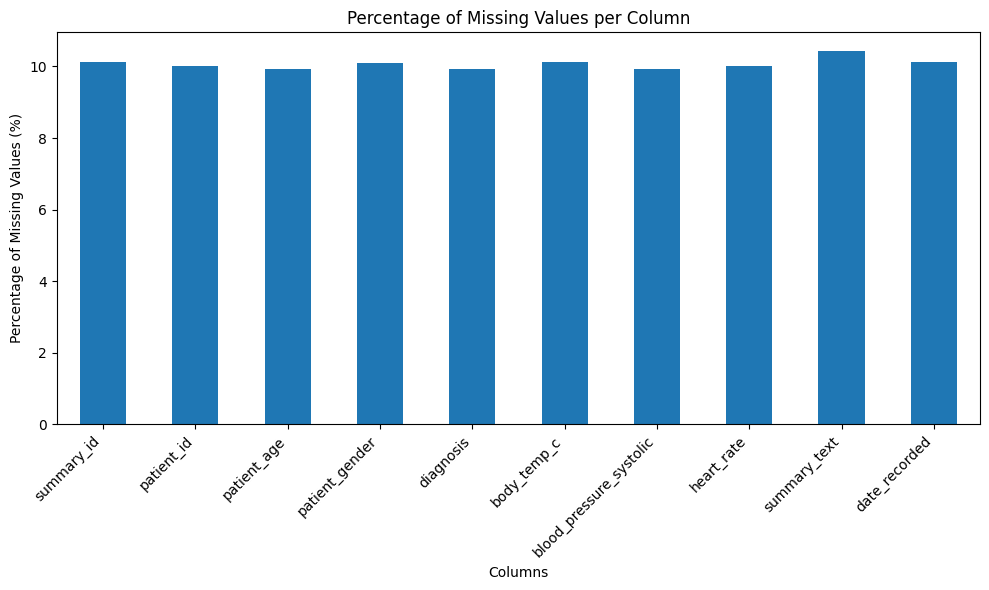

In [ ]:
# Calculate the percentage of missing values for each column
missing_percentage = df.isnull().sum() / len(df) * 100

# Create a bar plot of missing value percentages
plt.figure(figsize=(10, 6))
missing_percentage.plot(kind='bar')
plt.title('Percentage of Missing Values per Column')
plt.xlabel('Columns')
plt.ylabel('Percentage of Missing Values (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

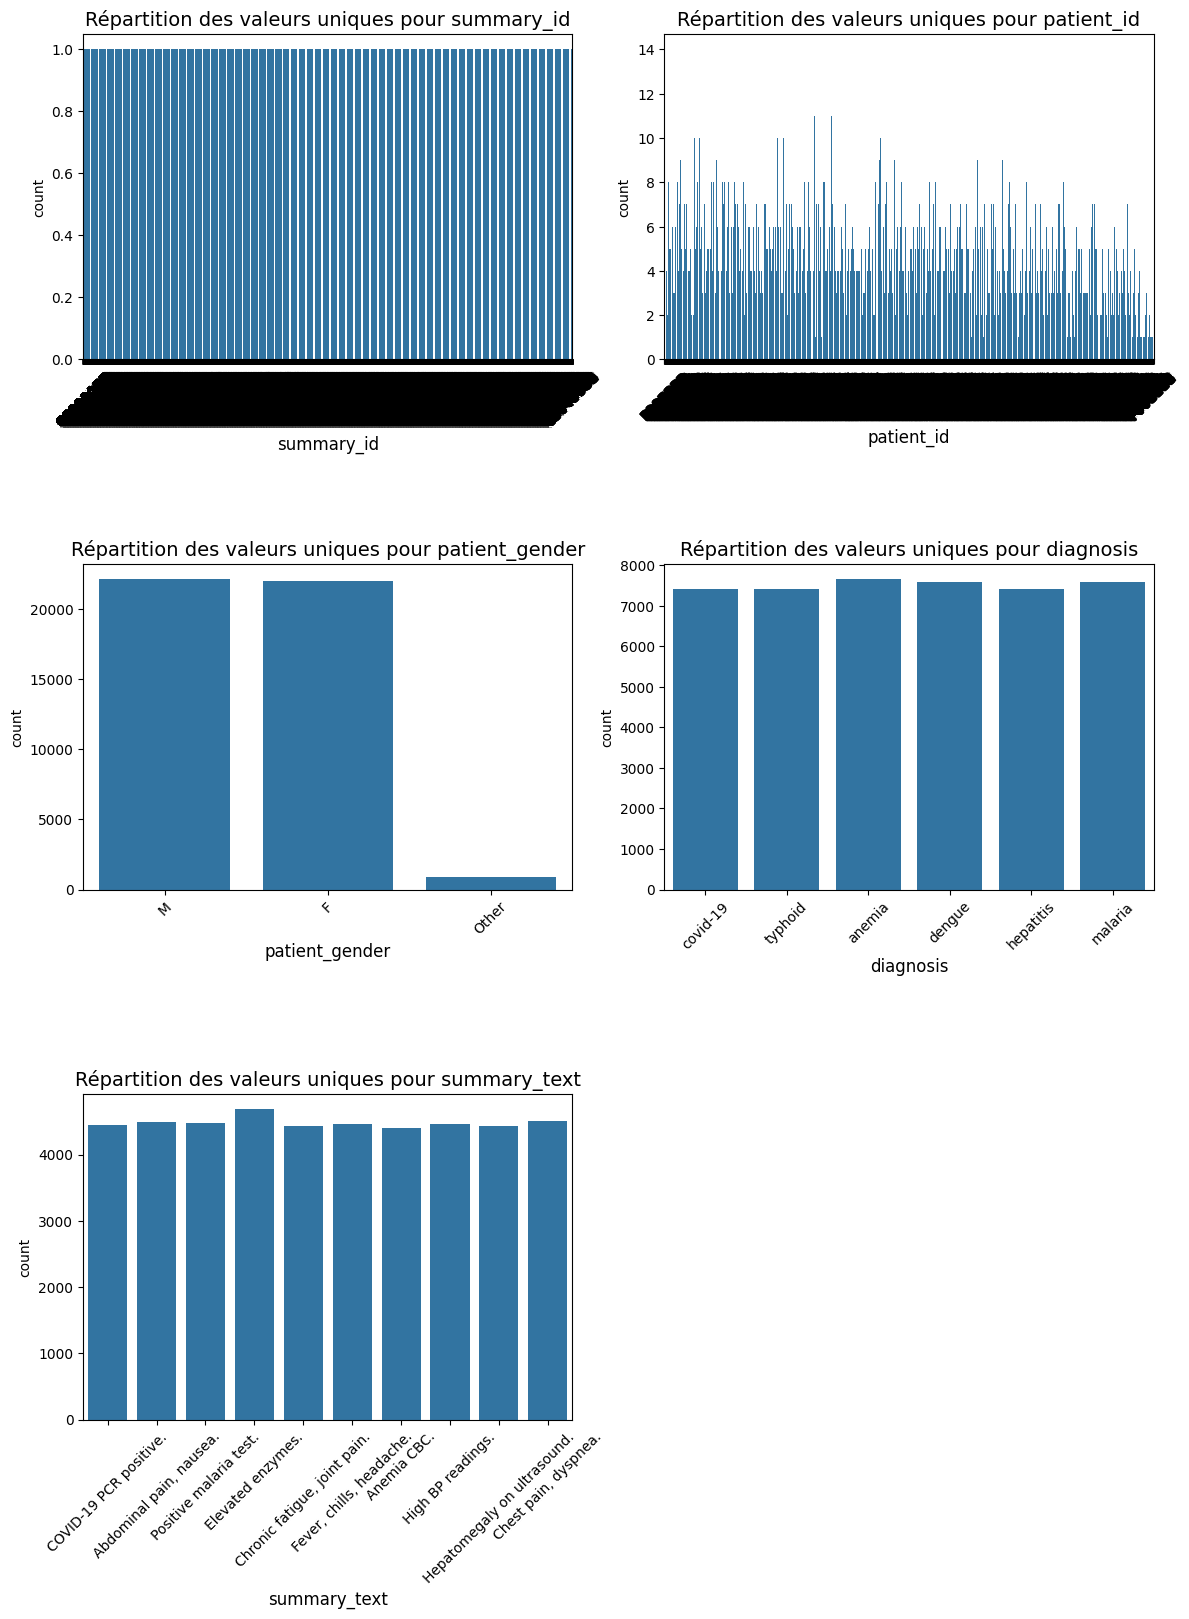

In [ ]:
columns = df.select_dtypes(include=['object']).columns
plt.figure(figsize=(12, 25))
i = 1
for col in columns:
    plt.subplot(5, 2, i)
    sns.countplot(x=col, data=df)
    plt.title(f'Répartition des valeurs uniques pour {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.xticks(rotation=45)
    i += 1
plt.tight_layout()
plt.show()

In [ ]:
# Afficher les valeurs uniques pour chaque colonne catégorielle
print(f"Unique values in summary id: {df['summary_id'].unique()}")
print(f"Number of unique values in {'summary_id'}: {df['summary_id'].nunique()}")


Unique values in summary id: ['CS000001' 'CS000002' 'CS000003' ... 'CS049997' 'CS049998' 'CS049999']
Number of unique values in summary_id: 44939


In [ ]:
print(f"Unique values in summary id: {df['patient_age'].unique()}")
print(f"Number of unique values in {'patient_age'}: {df['patient_age'].nunique()}")

Unique values in summary id: [ 6.10000000e+01             nan  2.00000000e+01  2.50000000e+01
  4.80000000e+01  3.60000000e+01  8.40000000e+01  6.20000000e+01
  7.90000000e+01  5.90000000e+01  5.00000000e+01  4.50000000e+01
  6.30000000e+01  7.20000000e+01  2.30000000e+01  1.80000000e+01
  7.30000000e+01  3.10000000e+01  3.70000000e+01  8.70000000e+01
  7.60000000e+01  4.20000000e+01  4.60000000e+01  4.40000000e+01
  4.30000000e+01  3.40000000e+01  5.20000000e+01  7.80000000e+01
  3.80000000e+01  8.90000000e+01  5.40000000e+01  8.50000000e+01
  2.20000000e+01  6.60000000e+01  2.60000000e+01  2.90000000e+01
  3.20000000e+01  3.90000000e+01  2.10000000e+01  5.30000000e+01
  2.70000000e+01  4.70000000e+01  6.70000000e+01  2.40000000e+01
  5.10000000e+01  8.80000000e+01  6.80000000e+01  8.00000000e+01
  6.90000000e+01  5.60000000e+01  7.50000000e+01 -3.40530726e+01
  6.50000000e+01  3.30000000e+01  7.10000000e+01  3.00000000e+01
  3.50000000e+01  4.00000000e+01  4.10000000e+01  6.00000000e

In [ ]:
df['patient_age'] = df['patient_age'].apply(lambda x: x if x>0 else -x)

In [ ]:
df[df['patient_age']==0]

,summary_id,patient_id,patient_age,patient_gender,diagnosis,body_temp_c,blood_pressure_systolic,heart_rate,summary_text,date_recorded


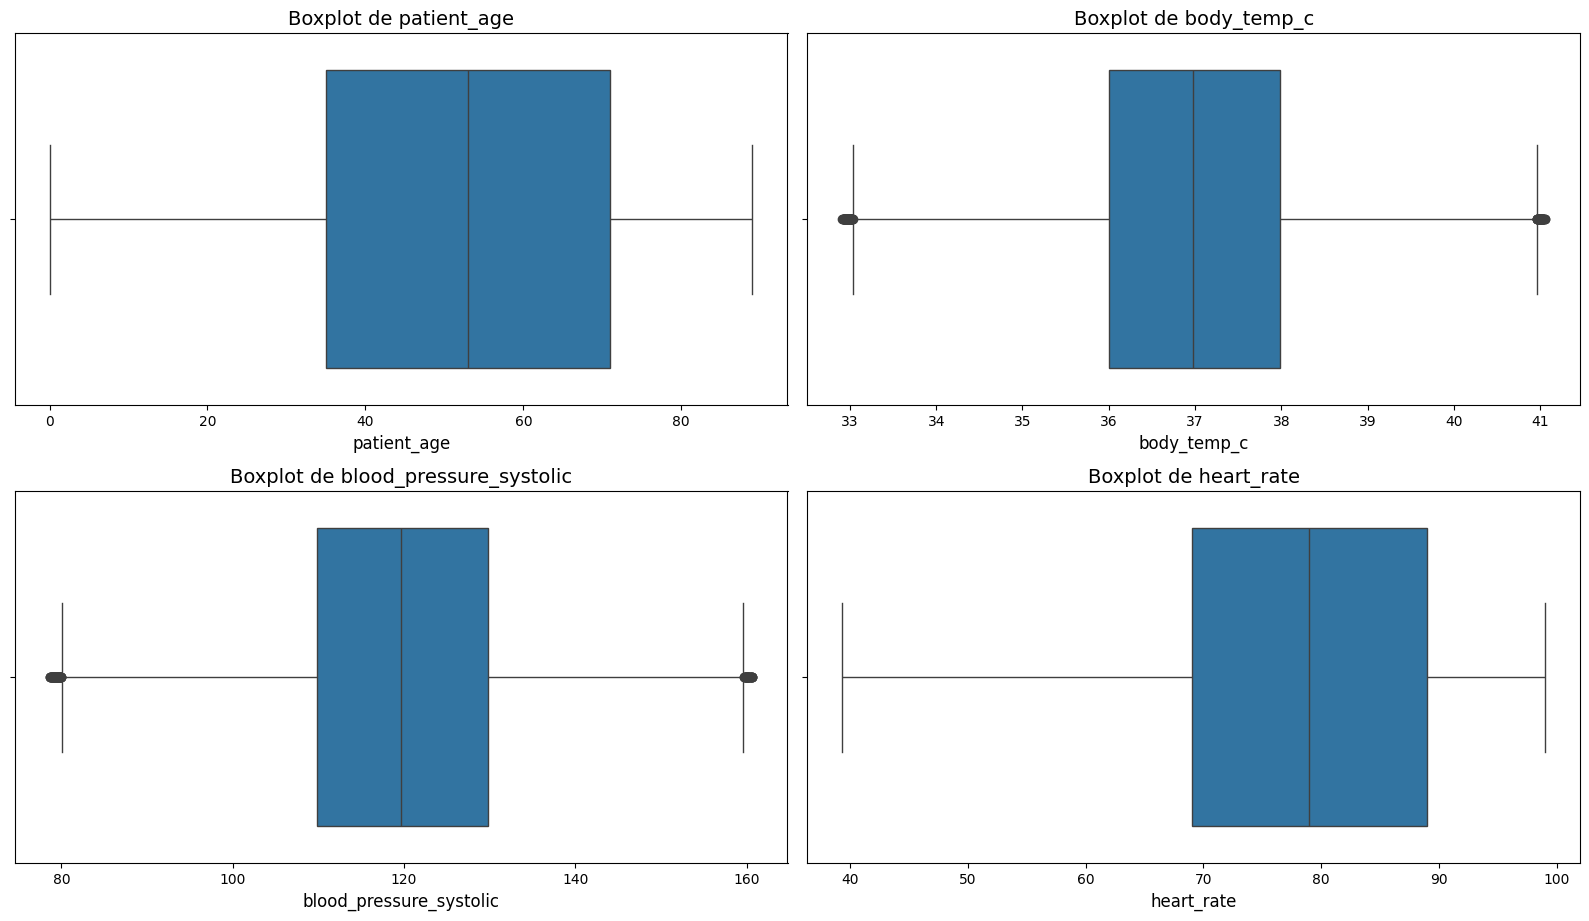

In [ ]:
# Liste des colonnes numériques

# Création des boxplots
plt.figure(figsize=(16, 18))
i = 1
for col in num_df:
    plt.subplot(4, 2, i)
    sns.boxplot(x=col, data=df)
    plt.title(f'Boxplot de {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    i += 1
plt.tight_layout()
plt.show()

In [ ]:
df.dropna(inplace=True)

In [ ]:
# Handle outliers using IQR method for numerical columns
numerical_cols = ['patient_age', 'body_temp_c', 'blood_pressure_systolic', 'heart_rate']

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Remove outliers
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print("Shape of the DataFrame after outlier removal:", df.shape)

Shape of the DataFrame after outlier removal: (16798, 10)


In [ ]:
# Impute missing values in numerical columns with the median
numerical_cols = ['body_temp_c', 'blood_pressure_systolic', 'heart_rate']
for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Impute missing values in categorical columns with a placeholder
categorical_cols = ['summary_id', 'patient_id', 'patient_gender', 'diagnosis', 'summary_text']
for col in categorical_cols:
    df[col].fillna('Unknown', inplace=True)

print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
summary_id                 0
patient_id                 0
patient_age                0
patient_gender             0
diagnosis                  0
body_temp_c                0
blood_pressure_systolic    0
heart_rate                 0
summary_text               0
date_recorded              0
dtype: int64


/tmp/ipython-input-10-2736101415.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipython-input-10-2736101415.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [ ]:
# Replace outliers with the median using IQR method for numerical columns
numerical_cols = ['body_temp_c', 'blood_pressure_systolic', 'heart_rate']

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Replace outliers with the median
    median_val = df[col].median()
    df[col] = np.where(df[col] < lower_bound, median_val, df[col])
    df[col] = np.where(df[col] > upper_bound, median_val, df[col])

print("Outliers replaced with median for numerical columns.")

Outliers replaced with median for numerical columns.


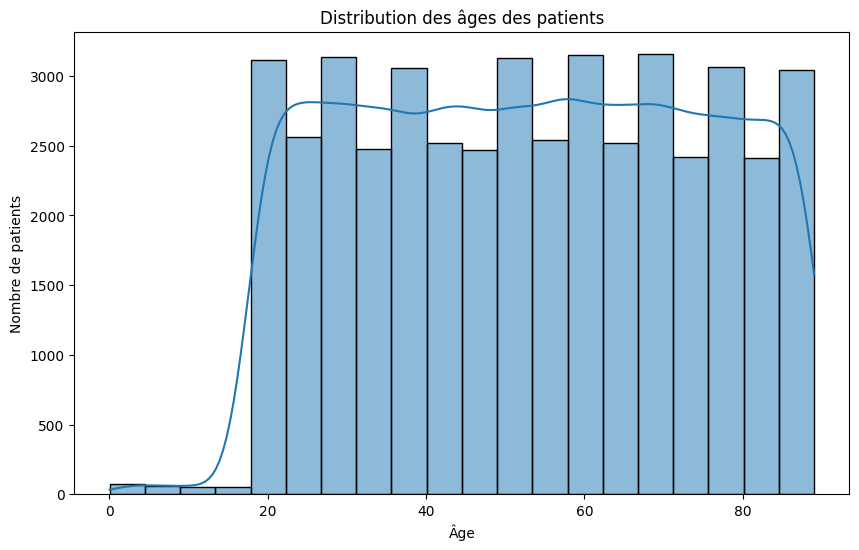

In [ ]:
# Visualisation de la distribution des âges
plt.figure(figsize=(10, 6))
sns.histplot(df['patient_age'], bins=20, kde=True)
plt.title('Distribution des âges des patients')
plt.xlabel('Âge')
plt.ylabel('Nombre de patients')
plt.show()

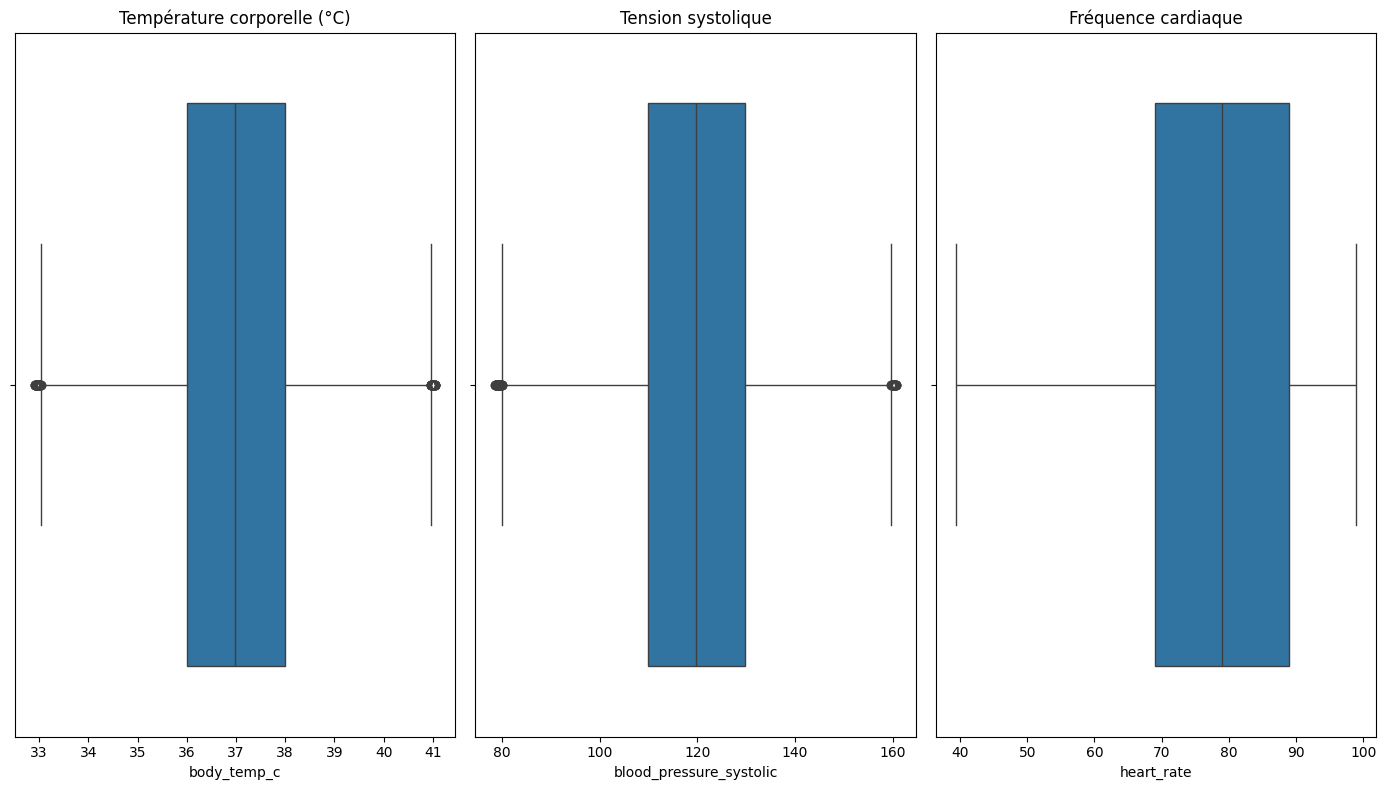

In [ ]:
# Boxplot des mesures vitales
plt.figure(figsize=(14, 8))
plt.subplot(1, 3, 1)
sns.boxplot(x=df['body_temp_c'])
plt.title('Température corporelle (°C)')

plt.subplot(1, 3, 2)
sns.boxplot(x=df['blood_pressure_systolic'])
plt.title('Tension systolique')

plt.subplot(1, 3, 3)
sns.boxplot(x=df['heart_rate'])
plt.title('Fréquence cardiaque')

plt.tight_layout()
plt.show()

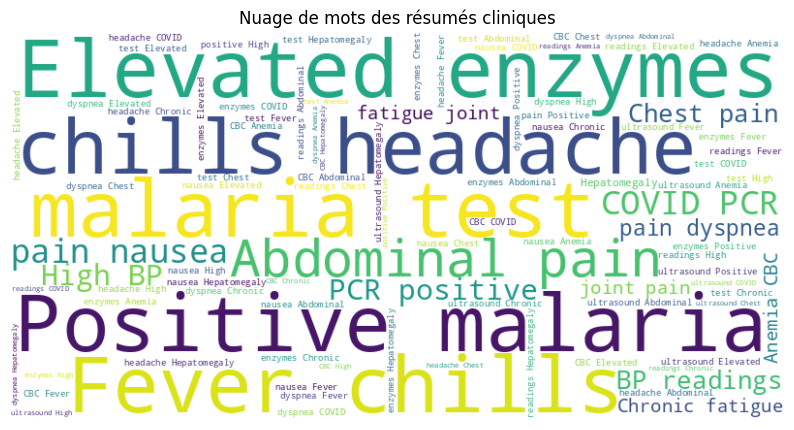

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Concaténer tous les résumés cliniques
all_summaries = ' '.join(df['summary_text'].dropna().astype(str))

# Créer un nuage de mots
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_summaries)

# Visualisation
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nuage de mots des résumés cliniques')
plt.show()

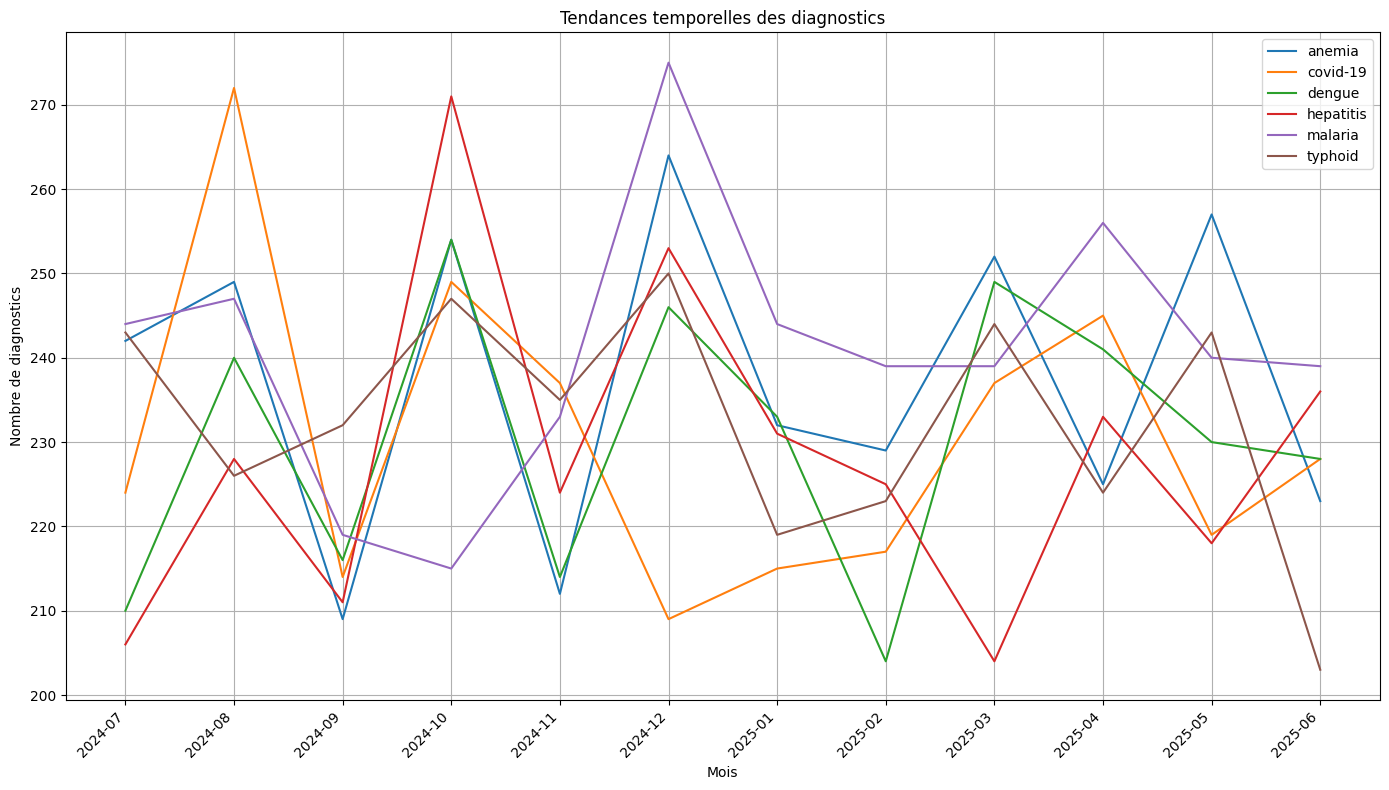

In [ ]:
# Convert the date_recorded column to datetime format
df['date_recorded'] = pd.to_datetime(df['date_recorded'], errors='coerce')

# Add columns for year and month
df['year'] = df['date_recorded'].dt.year
df['month'] = df['date_recorded'].dt.month

# Calculate the number of diagnostics by month
# Drop rows where date_recorded is NaN after coercion
monthly_diagnosis = df.dropna(subset=['date_recorded']).groupby(['year', 'month', 'diagnosis']).size().unstack().fillna(0)

# Create a string representation of the date for the x-axis
monthly_diagnosis_index_str = [f'{int(y)}-{int(m):02d}' for y, m in monthly_diagnosis.index]

# Visualisation des tendances temporelles des diagnostics
plt.figure(figsize=(14, 8))
for diagnosis in monthly_diagnosis.columns:
    plt.plot(monthly_diagnosis_index_str, monthly_diagnosis[diagnosis], label=diagnosis)

plt.title('Tendances temporelles des diagnostics')
plt.xlabel('Mois')
plt.ylabel('Nombre de diagnostics')
plt.xticks(rotation=45, ha='right') # Rotate labels for readability
plt.legend()
plt.grid(True) # Add grid for better readability
plt.tight_layout()
plt.show()

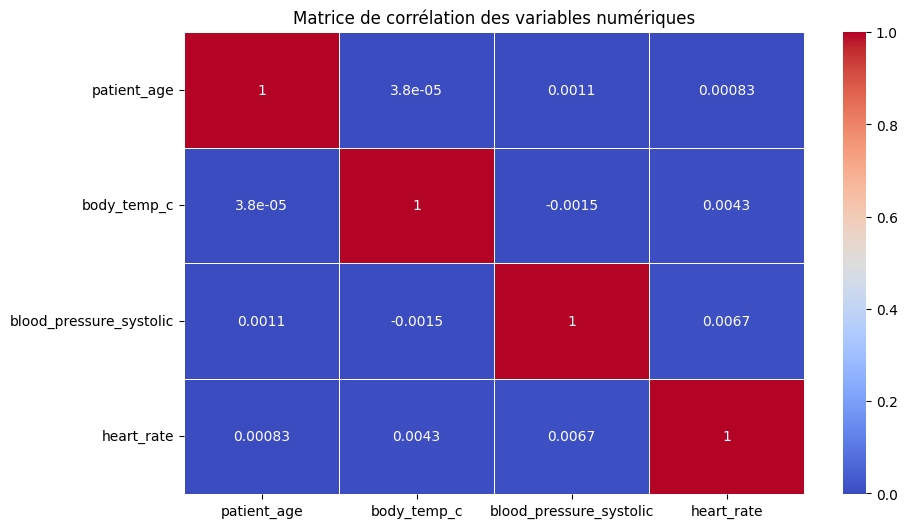

In [ ]:
# Calculer la matrice de corrélation
correlation_matrix = df[['patient_age', 'body_temp_c', 'blood_pressure_systolic', 'heart_rate']].corr()

# Visualisation
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matrice de corrélation des variables numériques')
plt.show()

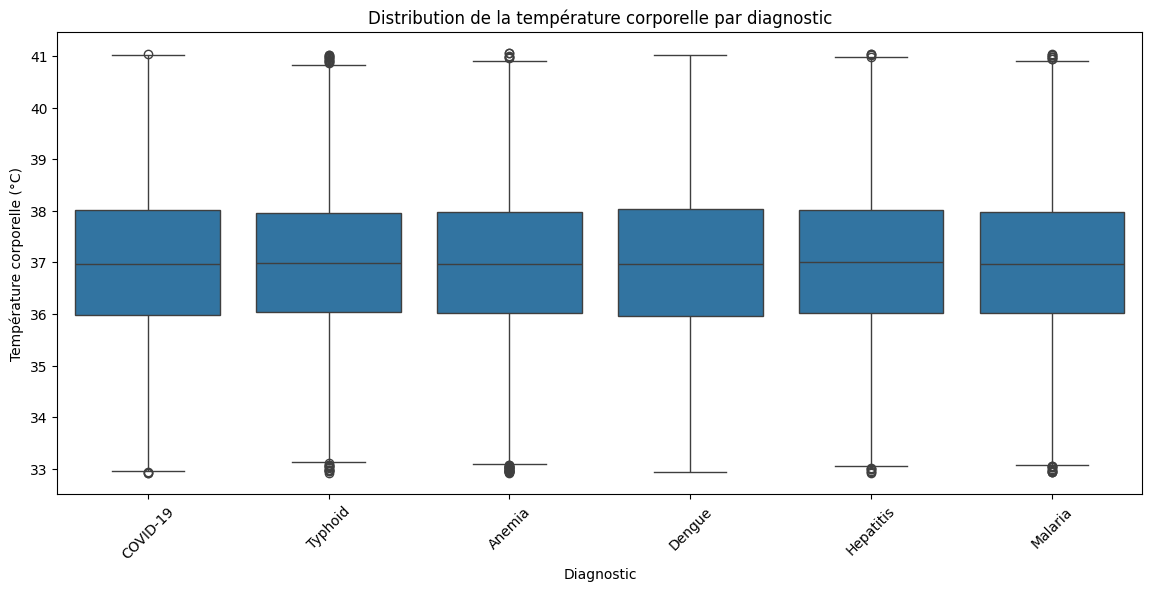

ANOVA Results for Body Temperature: F-statistic = 0.31676465200626575, p-value = 0.903195309450724


In [ ]:
# Boxplot de la température corporelle par diagnostic
plt.figure(figsize=(14, 6))
sns.boxplot(x='diagnosis', y='body_temp_c', data=df)
plt.title('Distribution de la température corporelle par diagnostic')
plt.xlabel('Diagnostic')
plt.ylabel('Température corporelle (°C)')
plt.xticks(rotation=45)
plt.show()

# ANOVA pour tester les différences de moyenne de la température corporelle par diagnostic
from scipy.stats import f_oneway

anova_results = f_oneway(*[group['body_temp_c'].dropna() for name, group in df.groupby('diagnosis')])
print(f"ANOVA Results for Body Temperature: F-statistic = {anova_results.statistic}, p-value = {anova_results.pvalue}")

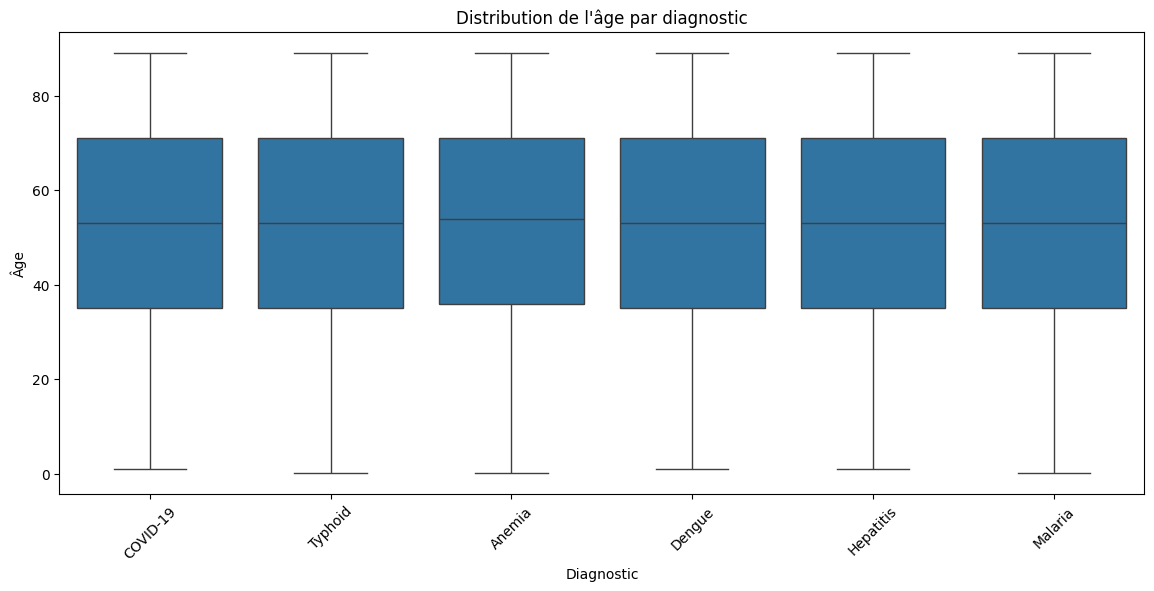

ANOVA Results for Patient Age: F-statistic = 0.41229980098516766, p-value = 0.8405683693932486


In [ ]:
# Boxplot de l'âge par diagnostic
plt.figure(figsize=(14, 6))
sns.boxplot(x='diagnosis', y='patient_age', data=df)
plt.title('Distribution de l\'âge par diagnostic')
plt.xlabel('Diagnostic')
plt.ylabel('Âge')
plt.xticks(rotation=45)
plt.show()

# ANOVA pour tester les différences de moyenne de l'âge par diagnostic
anova_results = f_oneway(*[group['patient_age'].dropna() for name, group in df.groupby('diagnosis')])
print(f"ANOVA Results for Patient Age: F-statistic = {anova_results.statistic}, p-value = {anova_results.pvalue}")

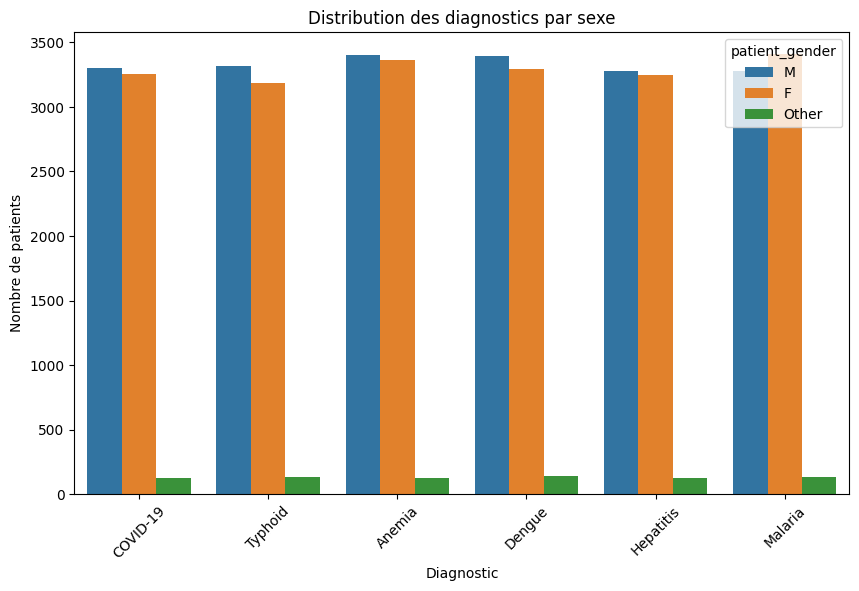

Chi-Square Test Results: Chi2 = 7.927985282699988, p-value = 0.635871196422029


In [ ]:
# Barplot du diagnostic par sexe
plt.figure(figsize=(10, 6))
sns.countplot(x='diagnosis', hue='patient_gender', data=df)
plt.title('Distribution des diagnostics par sexe')
plt.xlabel('Diagnostic')
plt.ylabel('Nombre de patients')
plt.xticks(rotation=45)
plt.show()

# Test du chi-carré pour examiner l'association entre sexe et diagnostic
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['patient_gender'], df['diagnosis'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-Square Test Results: Chi2 = {chi2}, p-value = {p}")

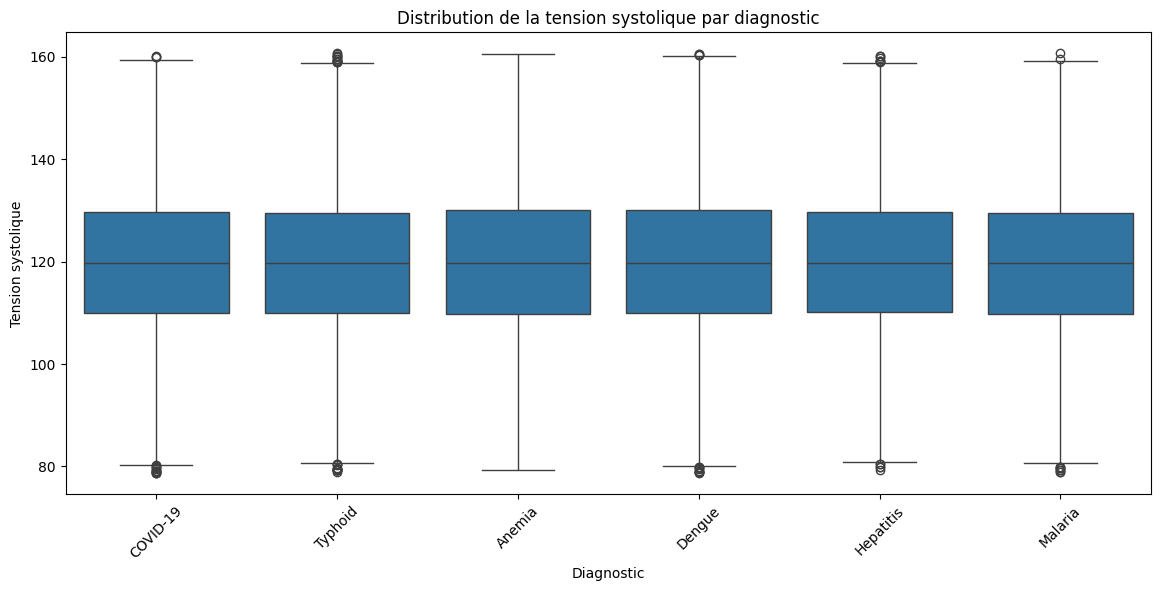

ANOVA Results for Systolic Blood Pressure: F-statistic = 0.9956730101174622, p-value = 0.41854114083472727


In [ ]:
# Boxplot de la tension systolique par diagnostic
plt.figure(figsize=(14, 6))
sns.boxplot(x='diagnosis', y='blood_pressure_systolic', data=df)
plt.title('Distribution de la tension systolique par diagnostic')
plt.xlabel('Diagnostic')
plt.ylabel('Tension systolique')
plt.xticks(rotation=45)
plt.show()

# ANOVA pour tester les différences de moyenne de la tension systolique par diagnostic
anova_results = f_oneway(*[group['blood_pressure_systolic'].dropna() for name, group in df.groupby('diagnosis')])
print(f"ANOVA Results for Systolic Blood Pressure: F-statistic = {anova_results.statistic}, p-value = {anova_results.pvalue}")

In [ ]:
df

,summary_id,patient_id,patient_age,patient_gender,diagnosis,body_temp_c,blood_pressure_systolic,heart_rate,summary_text,date_recorded,year,month
0,CS000001,P002538,61.0,M,covid-19,34.416801,126.632921,92.0,COVID-19 PCR positive.,2024-08-14,2024,8
3,CS000004,P004611,25.0,M,anemia,39.070247,123.192566,71.0,Positive malaria test.,2025-06-11,2025,6
7,CS000008,P007031,84.0,F,typhoid,34.224721,137.979799,78.0,Positive malaria test.,2024-08-25,2024,8
9,CS000010,P005627,79.0,F,hepatitis,37.640062,116.091576,66.0,"Fever, chills, headache.",2025-05-15,2025,5
10,CS000011,P007282,59.0,F,hepatitis,36.084522,112.288941,76.0,Anemia CBC.,2025-03-01,2025,3
...,...,...,...,...,...,...,...,...,...,...,...,...
49994,CS049995,P007649,82.0,M,anemia,38.271811,112.473048,67.0,"Chest pain, dyspnea.",2025-04-13,2025,4
49995,CS049996,P006008,61.0,M,hepatitis,36.257456,98.380371,81.0,Hepatomegaly on ultrasound.,2025-03-29,2025,3
49996,CS049997,P008077,19.0,F,typhoid,37.240056,118.656196,66.0,High BP readings.,2024-11-16,2024,11
49997,CS049998,P007257,71.0,M,hepatitis,36.956619,119.175791,79.0,Elevated enzymes.,2024-12-27,2024,12


In [ ]:
#test_id = df['patient_id'].iloc[5]
occ = {}
for id in enumerate(df['patient_id']):
  df_id = df[df['patient_id'] == id[1]]
  occ[id] = len(df_id)


In [ ]:
#occ
df_occ = pd.DataFrame(occ.items(), columns=['id', 'occ'])

In [ ]:
df_occ['id2'] = df_occ['id'].apply(lambda x: x[1])

In [ ]:
df_occ.drop(columns=['id'], inplace=True)

In [ ]:
df_occ

,occ,id2
0,2,P002538
1,6,P004611
2,1,P007031
3,2,P005627
4,4,P007282
...,...,...
16793,3,P007649
16794,4,P006008
16795,3,P008077
16796,3,P007257


# Task
Explain the provided code and then, for patients with duplicate IDs, if their gender is different, replace it with 'Unknown', and if their age is different, replace it with the median of their different ages.

## Identify duplicate patient ids

### Subtask:
Find patient IDs that appear more than once in the dataset.


**Reasoning**:
Count the occurrences of each patient ID and filter for those appearing more than once to identify duplicate patient IDs.



In [ ]:
# Count the occurrences of each unique value in the 'patient_id' column
patient_id_counts = df['patient_id'].value_counts()

# Filter the results to identify patient IDs that have a count greater than 1
duplicate_patient_ids = patient_id_counts[patient_id_counts > 1].index.tolist()

print("Duplicate Patient IDs:", duplicate_patient_ids)

Duplicate Patient IDs: ['P001228', 'P005783', 'P006889', 'P002822', 'P002522', 'P005996', 'P002968', 'P000410', 'P009134', 'P007681', 'P005900', 'P002724', 'P008044', 'P003527', 'P003501', 'P009854', 'P009887', 'P002603', 'P006810', 'P006428', 'P003554', 'P006122', 'P001477', 'P008936', 'P008946', 'P001872', 'P002915', 'P005803', 'P008603', 'P008554', 'P002649', 'P005935', 'P000306', 'P003597', 'P006919', 'P003709', 'P008642', 'P005188', 'P002568', 'P005769', 'P004015', 'P009905', 'P008092', 'P009576', 'P008954', 'P005116', 'P005453', 'P009991', 'P009545', 'P005979', 'P005881', 'P008901', 'P001491', 'P009753', 'P005546', 'P005732', 'P000809', 'P005662', 'P001078', 'P002468', 'P003476', 'P008984', 'P000081', 'P009613', 'P005021', 'P009605', 'P004132', 'P004611', 'P002656', 'P009191', 'P001464', 'P004113', 'P005551', 'P005786', 'P009158', 'P004690', 'P006017', 'P002654', 'P005844', 'P005239', 'P004248', 'P004173', 'P008994', 'P005761', 'P001793', 'P005170', 'P001567', 'P007909', 'P003011

## Check for gender inconsistencies

### Subtask:
For each duplicate patient ID, check if the 'patient_gender' is the same across all entries. If not, update the 'patient_gender' to 'Unknown' for all entries with that patient ID.


**Reasoning**:
Iterate through duplicate patient IDs, check for gender inconsistencies, and update gender to 'Unknown' if different.



In [ ]:
# Iterate through the duplicate_patient_ids list
for patient_id in duplicate_patient_ids:
    # Filter the DataFrame df to get all rows corresponding to that patient_id
    patient_df = df[df['patient_id'] == patient_id]

    # Check if all unique values in the 'patient_gender' column for the filtered DataFrame are the same
    unique_genders = patient_df['patient_gender'].unique()

    # If the number of unique values in 'patient_gender' for the filtered DataFrame is greater than 1,
    # set the 'patient_gender' to 'Unknown' for all rows in df that match the current patient_id.
    if len(unique_genders) > 1:
        df.loc[df['patient_id'] == patient_id, 'patient_gender'] = 'Unknown'

print("Gender inconsistencies for duplicate patient IDs handled.")

Gender inconsistencies for duplicate patient IDs handled.


## Check for age inconsistencies and calculate median

### Subtask:
For each duplicate patient ID, check if the 'patient_age' is the same across all entries. If not, calculate the median of the different ages for that patient ID.


**Reasoning**:
Iterate through duplicate patient IDs, filter the DataFrame, check for age consistency, and calculate the median age for inconsistent entries.



In [ ]:
# Dictionary to store median ages for patient IDs with inconsistent ages
median_ages = {}

# Iterate through the duplicate_patient_ids list
for patient_id in duplicate_patient_ids:
    # Filter the DataFrame df to get all rows corresponding to that patient_id
    patient_df = df[df['patient_id'] == patient_id]

    # Check if all unique values in the 'patient_age' column for the filtered DataFrame are the same
    unique_ages = patient_df['patient_age'].unique()

    # If the number of unique values in 'patient_age' for the filtered DataFrame is greater than 1,
    # calculate the median of the 'patient_age' for those rows and store it.
    if len(unique_ages) > 1:
        median_age = patient_df['patient_age'].median()
        median_ages[patient_id] = median_age

print("Median ages calculated for patient IDs with inconsistent ages:", median_ages)

Median ages calculated for patient IDs with inconsistent ages: {'P001228': 28.0, 'P005783': 27.5, 'P006889': 54.0, 'P002822': 46.0, 'P002522': 37.0, 'P005996': 56.0, 'P002968': 52.0, 'P000410': 48.0, 'P009134': 39.0, 'P007681': 66.0, 'P005900': 46.0, 'P002724': 45.0, 'P008044': 52.0, 'P003527': 61.0, 'P003501': 64.5, 'P009854': 34.0, 'P009887': 30.5, 'P002603': 68.0, 'P006810': 42.5, 'P006428': 56.5, 'P003554': 51.5, 'P006122': 70.0, 'P001477': 40.0, 'P008936': 68.5, 'P008946': 70.5, 'P001872': 49.0, 'P002915': 65.5, 'P005803': 65.5, 'P008603': 53.0, 'P008554': 58.5, 'P002649': 28.0, 'P005935': 46.5, 'P000306': 57.5, 'P003597': 58.0, 'P006919': 50.5, 'P003709': 63.0, 'P008642': 53.0, 'P005188': 68.0, 'P002568': 45.5, 'P005769': 57.0, 'P004015': 42.5, 'P009905': 56.0, 'P008092': 74.0, 'P009576': 63.5, 'P008954': 69.0, 'P005116': 52.5, 'P005453': 67.0, 'P009991': 45.0, 'P009545': 35.0, 'P005979': 67.5, 'P005881': 62.0, 'P008901': 72.5, 'P001491': 61.5, 'P009753': 57.5, 'P005546': 63.5, '

**Reasoning**:
Replace the inconsistent ages with the calculated median age for each duplicate patient ID.



In [ ]:
# For each patient ID in the median_ages dictionary, replace the 'patient_age' in the DataFrame
for patient_id, median_age in median_ages.items():
    df.loc[df['patient_id'] == patient_id, 'patient_age'] = median_age

print("Inconsistent patient ages replaced with median values.")

Inconsistent patient ages replaced with median values.


## Summary:

### Data Analysis Key Findings

*   Duplicate patient IDs were identified in the dataset.
*   For duplicate patient IDs, gender inconsistencies were checked. If different genders were found for the same patient ID, the gender for all entries of that ID was replaced with 'Unknown'.
*   For duplicate patient IDs, age inconsistencies were checked. If different ages were found for the same patient ID, the median of those different ages was calculated and replaced the original age values for all entries of that ID.

### Insights or Next Steps

*   Investigate the source of duplicate patient IDs and inconsistent data to prevent future occurrences.
*   Consider establishing data validation rules during data entry to ensure data consistency.


In [ ]:
len(df[df['patient_gender'] == 'Unknown'])

9663

In [ ]:
df.to_csv('clinical_summaries_cleaned.csv', index=False)

In [ ]:
def get_diagnosis_by_date(df, patient_id, start_date, end_date):
    """
    Retrieves the diagnosis for a specific patient within a given date range.

    Args:
        df (pd.DataFrame): The DataFrame containing clinical summaries.
        patient_id (str): The ID of the patient.
        start_date (str or datetime): The start date of the range.
        end_date (str or datetime): The end date of the range.

    Returns:
        pd.Series: A Series of diagnoses for the patient within the date range.
    """
    # Ensure date columns are datetime objects
    df['date_recorded'] = pd.to_datetime(df['date_recorded'])
    start_date = pd.to_datetime(start_date)
    end_date = pd.to_datetime(end_date)

    # Filter by patient ID and date range
    patient_df = df[(df['patient_id'] == patient_id) &
                    (df['date_recorded'] >= start_date) &
                    (df['date_recorded'] <= end_date)]

    return patient_df['diagnosis']

In [ ]:
patient_summaries = df[df["patient_id"] == "P002538"][["date_recorded","diagnosis", "summary_text"]].values.tolist()
print(patient_summaries)

[[Timestamp('2024-08-14 00:00:00'), 'covid-19', 'COVID-19 PCR positive.'], [Timestamp('2025-02-10 00:00:00'), 'malaria', 'Fever, chills, headache.']]


In [ ]:
liste_des_dates = df[df["patient_id"] == "P002538"][["date_recorded","diagnosis","summary_text"]]


In [ ]:
liste_des_dates

,date_recorded,diagnosis,summary_text
0,2024-08-14,covid-19,COVID-19 PCR positive.
10849,2025-02-10,malaria,"Fever, chills, headache."


In [ ]:
df["patient_id"].unique().shape

(8124,)

In [ ]:
def get_patient_summary_by_date(patient_id: str):
        liste_des_dates = df[df["patient_id"] == "P002538"][["date_recorded","diagnosis", "summary_text"]].values.tolist() # on recupere les dates et diagnostics
        patient_info = {patient_id : liste_des_dates}
        return patient_info

def get_patient_summary_with_date():
    # on retourne une liste de dictionnaire, chacun etant l'information cherche
    return {patient_id : get_patient_summary_by_date(patient_id) for patient_id in df["patient_id"].unique()}

In [ ]:
liste = get_patient_summary_with_date()

In [ ]:
liste["P002538"]

{'P002538': [[Timestamp('2024-08-14 00:00:00'),
   'covid-19',
   'COVID-19 PCR positive.'],
  [Timestamp('2025-02-10 00:00:00'), 'malaria', 'Fever, chills, headache.']]}